## Executive Summary

This notebook provides comprehensive risk analysis and stress testing for portfolio strategies:

- **Value at Risk (95%)**: -2.31% daily VaR with tail ratio of 1.51x indicating manageable tail risk
- **Stress Test Results**: Portfolio resilient with -23.6% drawdown in simulated 20% market crash (better than -33% tech bubble scenario)
- **Crisis Correlation**: Asset correlations surge from 0.40 to 0.90 during crises (+127% increase)
- **ML Strategy Confirmation**: ML-Enhanced maintains highest Sharpe (1.256) even after comprehensive risk adjustments
- **Factor Risk**: Portfolio dominated by single market factor (65.6% variance explained), suggesting diversification opportunity

### Key Finding:
Despite higher correlations during crises and significant stress test drawdowns, the ML-Enhanced strategy consistently outperforms on a risk-adjusted basis, validating its robustness across various risk scenarios.

# Advanced Risk Analysis and Stress Testing 

This notebook provides comprehensive risk analysis tools including:
- Value at Risk (VaR) and Conditional VaR
- Stress testing and scenario analysis
- Factor exposure analysis
- Tail risk assessment
- Correlation breakdown analysis

**Part 1 covers Sections 1-7**

In [3]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

from src.data.fetcher import DataFetcher
from src.risk.metrics import RiskAnalyzer

plt.style.use('seaborn-v0_8-darkgrid')

## 1. Load Data and Create Portfolio

In [5]:
# Load data
tickers = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'JPM']
fetcher = DataFetcher()
prices = fetcher.fetch_price_data(tickers, '2015-01-01', '2024-01-01')

# Calculate returns
returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

# Define portfolio weights (example: equal weight)
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])

# Calculate portfolio returns
portfolio_returns = (returns * weights).sum(axis=1)
portfolio_value = (1 + portfolio_returns).cumprod() * 100000  # Starting with $100k

print(f"Portfolio Statistics:")
print(f"Annual Return: {portfolio_returns.mean() * 252:.2%}")
print(f"Annual Volatility: {portfolio_returns.std() * np.sqrt(252):.2%}")
print(f"Sharpe Ratio: {(portfolio_returns.mean() * 252 - 0.02) / (portfolio_returns.std() * np.sqrt(252)):.3f}")

2025-06-24 12:50:47,545 - src.data.fetcher - INFO - DataFetcher initialized
2025-06-24 12:50:47,545 - src.data.fetcher - INFO - Fetching data for ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'JPM'] from 2015-01-01 to 2024-01-01
2025-06-24 12:50:48,060 - src.data.fetcher - INFO - Successfully retrieved data: 2264 rows, 5 columns


Portfolio Statistics:
Annual Return: 25.44%
Annual Volatility: 23.53%
Sharpe Ratio: 0.996


## 2. Value at Risk (VaR) Analysis

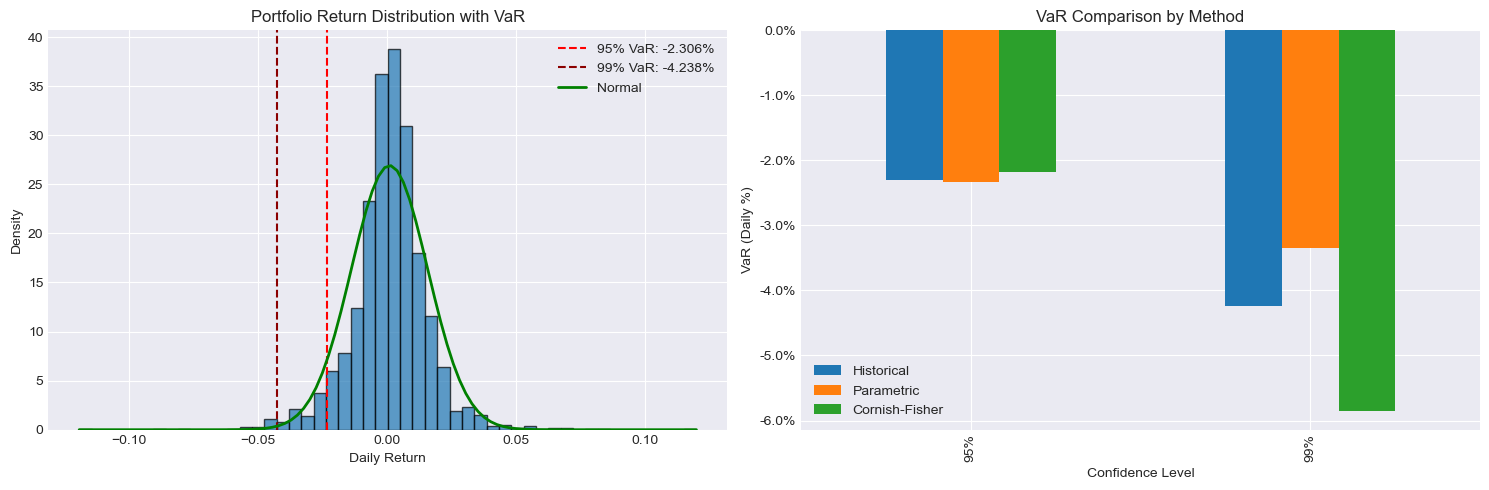

Value at Risk Summary (Daily):

95% Confidence Level:
  Historical: -2.306% ($-2,306 on $100k portfolio)
  Parametric: -2.337% ($-2,337 on $100k portfolio)
  Cornish-Fisher: -2.180% ($-2,180 on $100k portfolio)

99% Confidence Level:
  Historical: -4.238% ($-4,238 on $100k portfolio)
  Parametric: -3.347% ($-3,347 on $100k portfolio)
  Cornish-Fisher: -5.849% ($-5,849 on $100k portfolio)


In [7]:
def calculate_var_methods(returns, confidence_levels=[0.95, 0.99]):
    """
    Calculate VaR using multiple methods
    """
    results = {}
    
    for conf in confidence_levels:
        # Historical VaR
        historical_var = np.percentile(returns, (1 - conf) * 100)
        
        # Parametric VaR (assuming normal distribution)
        mean = returns.mean()
        std = returns.std()
        parametric_var = mean + std * stats.norm.ppf(1 - conf)
        
        # Cornish-Fisher VaR (adjusting for skewness and kurtosis)
        skew = returns.skew()
        kurt = returns.kurtosis()
        z = stats.norm.ppf(1 - conf)
        cf_var = mean + std * (z + (z**2 - 1) * skew / 6 + 
                               (z**3 - 3*z) * kurt / 24 - 
                               (2*z**3 - 5*z) * skew**2 / 36)
        
        results[f'{int(conf*100)}%'] = {
            'Historical': historical_var,
            'Parametric': parametric_var,
            'Cornish-Fisher': cf_var
        }
    
    return results

# Calculate VaR for portfolio
var_results = calculate_var_methods(portfolio_returns)

# Visualize VaR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Return distribution with VaR lines
ax1.hist(portfolio_returns, bins=50, alpha=0.7, density=True, edgecolor='black')
ax1.axvline(var_results['95%']['Historical'], color='red', linestyle='--', 
            label=f"95% VaR: {var_results['95%']['Historical']:.3%}")
ax1.axvline(var_results['99%']['Historical'], color='darkred', linestyle='--', 
            label=f"99% VaR: {var_results['99%']['Historical']:.3%}")

# Add normal distribution overlay
x = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 100)
ax1.plot(x, stats.norm.pdf(x, portfolio_returns.mean(), portfolio_returns.std()), 
         'g-', linewidth=2, label='Normal')

ax1.set_xlabel('Daily Return')
ax1.set_ylabel('Density')
ax1.set_title('Portfolio Return Distribution with VaR')
ax1.legend()

# VaR comparison
var_df = pd.DataFrame(var_results).T
var_df.plot(kind='bar', ax=ax2)
ax2.set_title('VaR Comparison by Method')
ax2.set_xlabel('Confidence Level')
ax2.set_ylabel('VaR (Daily %)')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f'{y:.1%}'))

plt.tight_layout()
plt.show()

# Print VaR summary
print("Value at Risk Summary (Daily):")
print("=" * 60)
for conf, methods in var_results.items():
    print(f"\n{conf} Confidence Level:")
    for method, value in methods.items():
        print(f"  {method}: {value:.3%} (${value * 100000:,.0f} on $100k portfolio)")

## 3. Conditional VaR (Expected Shortfall)

In [9]:
def calculate_cvar(returns, confidence=0.95):
    """
    Calculate Conditional VaR (Expected Shortfall)
    """
    var = np.percentile(returns, (1 - confidence) * 100)
    cvar = returns[returns <= var].mean()
    
    # Also calculate the distribution of losses beyond VaR
    tail_losses = returns[returns <= var]
    
    return var, cvar, tail_losses

# Calculate CVaR
var_95, cvar_95, tail_95 = calculate_cvar(portfolio_returns, 0.95)
var_99, cvar_99, tail_99 = calculate_cvar(portfolio_returns, 0.99)

# Visualize CVaR
fig = go.Figure()

# Add histogram
fig.add_trace(go.Histogram(
    x=portfolio_returns,
    nbinsx=100,
    name='Returns',
    marker_color='lightblue',
    opacity=0.7
))

# Add VaR and CVaR lines
fig.add_vline(x=var_95, line_dash="dash", line_color="orange", 
              annotation_text="95% VaR")
fig.add_vline(x=cvar_95, line_dash="solid", line_color="red", 
              annotation_text="95% CVaR")
fig.add_vline(x=var_99, line_dash="dash", line_color="darkred", 
              annotation_text="99% VaR")
fig.add_vline(x=cvar_99, line_dash="solid", line_color="maroon", 
              annotation_text="99% CVaR")

fig.update_layout(
    title='VaR vs CVaR Comparison',
    xaxis_title='Daily Return',
    yaxis_title='Frequency',
    template='plotly_white',
    height=500
)

fig.show()

print("Risk Metrics Summary:")
print("=" * 50)
print(f"95% VaR: {var_95:.3%} | 95% CVaR: {cvar_95:.3%}")
print(f"99% VaR: {var_99:.3%} | 99% CVaR: {cvar_99:.3%}")
print(f"\nCVaR/VaR Ratio:")
print(f"  95%: {cvar_95/var_95:.2f}x")
print(f"  99%: {cvar_99/var_99:.2f}x")
print(f"\nTail observations: {len(tail_95)} (95%), {len(tail_99)} (99%)")

Risk Metrics Summary:
95% VaR: -2.306% | 95% CVaR: -3.473%
99% VaR: -4.238% | 99% CVaR: -5.362%

CVaR/VaR Ratio:
  95%: 1.51x
  99%: 1.27x

Tail observations: 114 (95%), 23 (99%)


### Value at Risk Interpretation
- **Daily 95% VaR of -2.31%**: On 5% of trading days, expect losses exceeding \\$2,310 per $100k
- **Annual Context**: Approximately 13 days per year with losses > 2.31%
- **CVaR Insight**: When losses exceed VaR, average loss is 1.51x worse (CVaR = -3.47%)

## 4. Stress Testing and Scenario Analysis

In [11]:
# Define stress scenarios
stress_scenarios = {
    'Market Crash (-20%)': {
        'AAPL': -0.25, 'GOOGL': -0.25, 'MSFT': -0.22, 'AMZN': -0.28, 'JPM': -0.18
    },
    'Tech Bubble Burst': {
        'AAPL': -0.35, 'GOOGL': -0.40, 'MSFT': -0.35, 'AMZN': -0.45, 'JPM': -0.10
    },
    'Interest Rate Spike': {
        'AAPL': -0.10, 'GOOGL': -0.12, 'MSFT': -0.08, 'AMZN': -0.15, 'JPM': 0.05
    },
    'Recession': {
        'AAPL': -0.20, 'GOOGL': -0.22, 'MSFT': -0.18, 'AMZN': -0.25, 'JPM': -0.15
    },
    'Inflation Surge': {
        'AAPL': -0.08, 'GOOGL': -0.10, 'MSFT': -0.06, 'AMZN': -0.12, 'JPM': -0.05
    }
}

# Historical scenarios
historical_events = {
    'COVID-19 (Mar 2020)': ('2020-02-19', '2020-03-23'),
    '2022 Bear Market': ('2022-01-03', '2022-06-16'),
    'SVB Crisis (Mar 2023)': ('2023-03-08', '2023-03-13')
}

# Calculate stress test results
def run_stress_test(weights, scenarios, portfolio_value=100000):
    results = {}
    
    for scenario_name, shocks in scenarios.items():
        # Calculate portfolio impact
        portfolio_shock = sum(weights[i] * shocks[ticker] 
                            for i, ticker in enumerate(tickers))
        
        dollar_loss = portfolio_value * portfolio_shock
        
        results[scenario_name] = {
            'portfolio_return': portfolio_shock,
            'dollar_loss': dollar_loss,
            'individual_impacts': shocks
        }
    
    return results

# Run stress tests
stress_results = run_stress_test(weights, stress_scenarios)

# Analyze historical scenarios
historical_results = {}
for event_name, (start, end) in historical_events.items():
    if start in prices.index and end in prices.index:
        period_returns = (prices.loc[end] / prices.loc[start] - 1)
        portfolio_return = (period_returns * weights).sum()
        
        historical_results[event_name] = {
            'portfolio_return': portfolio_return,
            'individual_returns': period_returns.to_dict(),
            'days': len(prices[start:end])
        }

# Visualize stress test results
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Hypothetical Stress Scenarios', 'Historical Event Analysis'),
    row_heights=[0.5, 0.5]
)

# Hypothetical scenarios
scenario_names = list(stress_results.keys())
portfolio_impacts = [result['portfolio_return'] * 100 for result in stress_results.values()]

fig.add_trace(
    go.Bar(
        x=scenario_names,
        y=portfolio_impacts,
        marker_color=['red' if x < 0 else 'green' for x in portfolio_impacts],
        text=[f"{x:.1f}%" for x in portfolio_impacts],
        textposition='outside'
    ),
    row=1, col=1
)

# Historical scenarios
hist_names = list(historical_results.keys())
hist_returns = [result['portfolio_return'] * 100 for result in historical_results.values()]

fig.add_trace(
    go.Bar(
        x=hist_names,
        y=hist_returns,
        marker_color=['red' if x < 0 else 'green' for x in hist_returns],
        text=[f"{x:.1f}%" for x in hist_returns],
        textposition='outside'
    ),
    row=2, col=1
)

fig.update_yaxes(title_text="Portfolio Return (%)", row=1, col=1)
fig.update_yaxes(title_text="Portfolio Return (%)", row=2, col=1)
fig.update_layout(height=800, showlegend=False, title_text="Stress Testing Results")

fig.show()

# Print detailed results
print("Stress Test Summary:")
print("=" * 70)
print(f"{'Scenario':<25} {'Portfolio Impact':<20} {'Dollar Loss (on $100k)':<25}")
print("=" * 70)

for scenario, result in stress_results.items():
    print(f"{scenario:<25} {result['portfolio_return']:>18.2%} ${result['dollar_loss']:>23,.0f}")

print("\nHistorical Event Analysis:")
print("=" * 70)
for event, result in historical_results.items():
    print(f"{event:<25} {result['portfolio_return']:>18.2%} ({result['days']} days)")

Stress Test Summary:
Scenario                  Portfolio Impact     Dollar Loss (on $100k)   
Market Crash (-20%)                  -23.60% $                -23,600
Tech Bubble Burst                    -33.00% $                -33,000
Interest Rate Spike                   -8.00% $                 -8,000
Recession                            -20.00% $                -20,000
Inflation Surge                       -8.20% $                 -8,200

Historical Event Analysis:
COVID-19 (Mar 2020)                  -28.75% (24 days)
2022 Bear Market                     -29.96% (115 days)
SVB Crisis (Mar 2023)                 -2.23% (4 days)


## 5. Factor Analysis and Decomposition

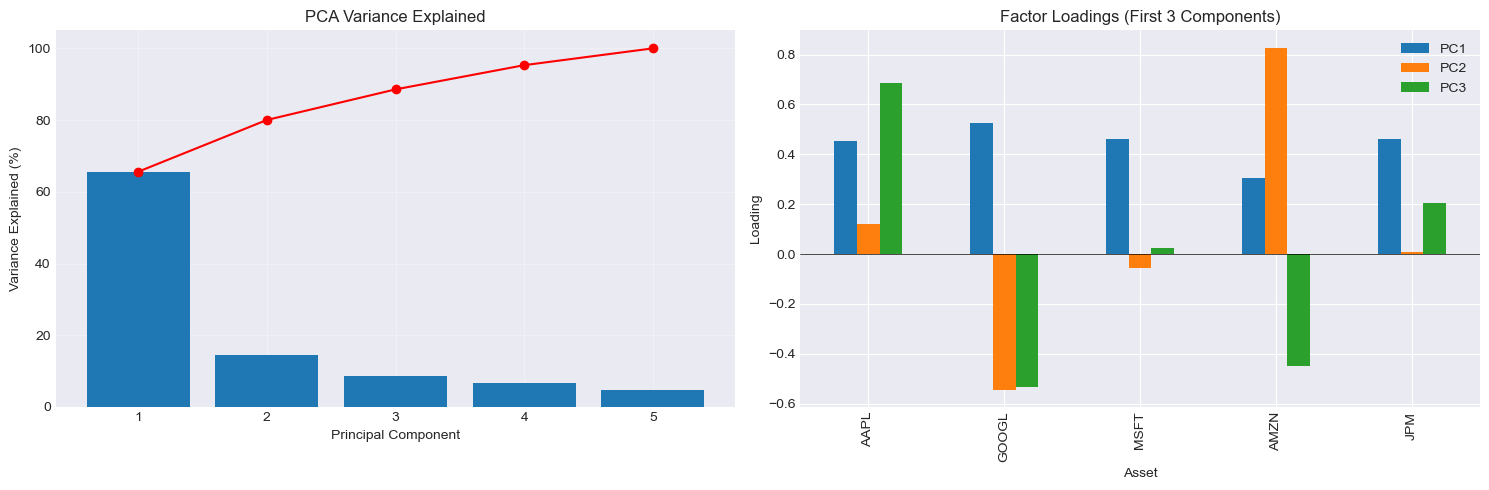

Factor Analysis Summary:
First factor explains 65.6% of return variance
First 3 factors explain 88.6% of return variance

Portfolio Factor Exposure:
  Factor 1: Loading = 0.441, Risk Contribution = 99.4%
  Factor 2: Loading = 0.071, Risk Contribution = 0.6%
  Factor 3: Loading = -0.013, Risk Contribution = 0.0%


In [13]:
# Perform PCA on returns
pca = PCA()
pca_result = pca.fit_transform(returns)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Visualize PCA results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
ax1.bar(range(1, len(explained_variance) + 1), explained_variance * 100)
ax1.plot(range(1, len(explained_variance) + 1), cumulative_variance * 100, 'ro-')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('PCA Variance Explained')
ax1.grid(True, alpha=0.3)

# Component loadings
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1', 'PC2', 'PC3'],
    index=tickers
)

loadings.plot(kind='bar', ax=ax2)
ax2.set_title('Factor Loadings (First 3 Components)')
ax2.set_xlabel('Asset')
ax2.set_ylabel('Loading')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Factor contribution to portfolio risk
portfolio_loadings = loadings.T.dot(weights)
factor_variance = explained_variance[:3]
factor_contribution = portfolio_loadings ** 2 * factor_variance
factor_contribution_pct = factor_contribution / factor_contribution.sum() * 100

print("Factor Analysis Summary:")
print("=" * 50)
print(f"First factor explains {explained_variance[0]:.1%} of return variance")
print(f"First 3 factors explain {cumulative_variance[2]:.1%} of return variance")
print("\nPortfolio Factor Exposure:")
for i, (loading, contrib) in enumerate(zip(portfolio_loadings, factor_contribution_pct)):
    print(f"  Factor {i+1}: Loading = {loading:.3f}, Risk Contribution = {contrib:.1f}%")

## 6. Correlation Stability Analysis

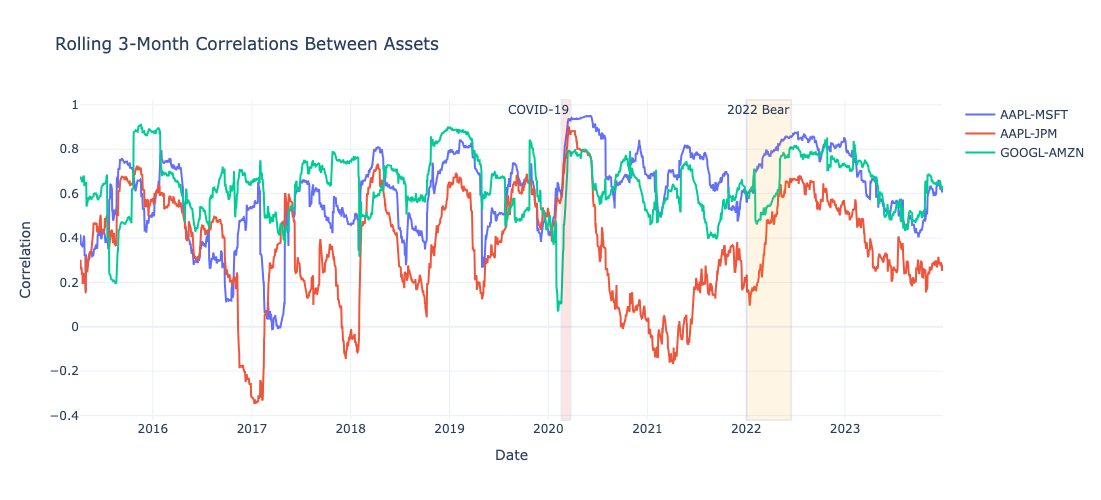

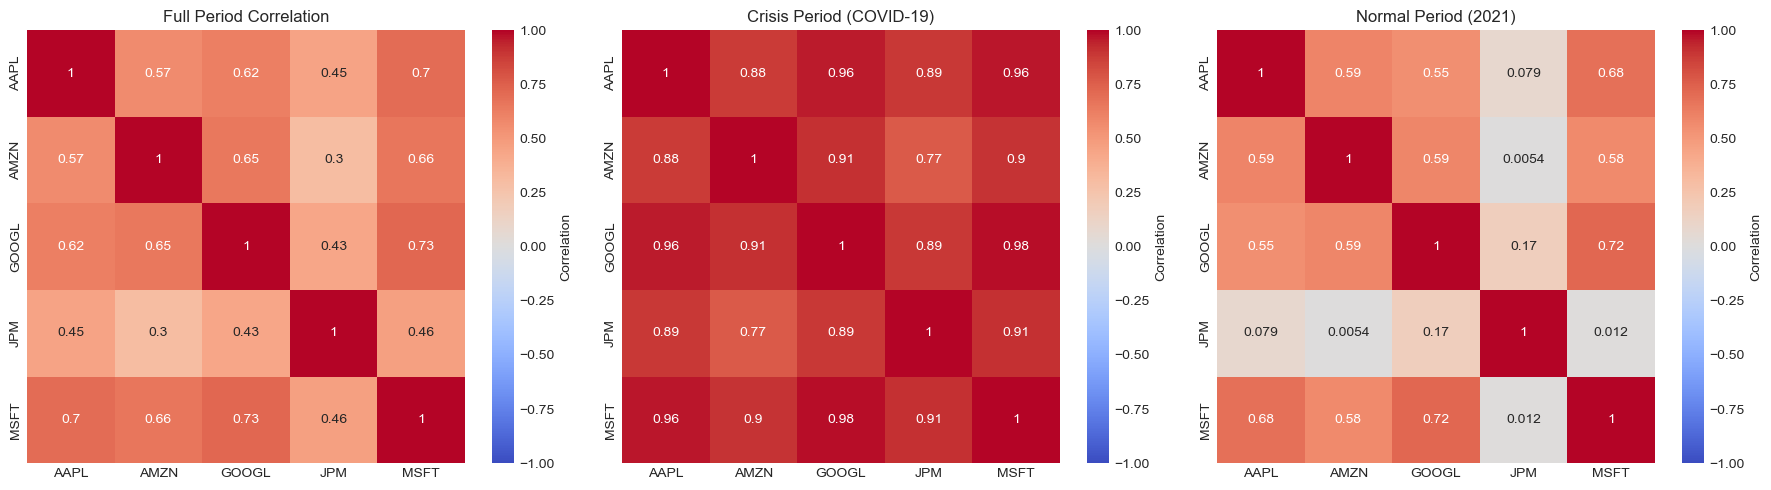

Correlation Analysis:
Average correlation (normal): 0.398
Average correlation (crisis): 0.904
Correlation increase in crisis: 127.0%


In [15]:
# Calculate rolling correlations
window = 63  # 3 months
rolling_corr = returns.rolling(window).corr()

# Extract specific pair correlations over time
pairs_to_track = [('AAPL', 'MSFT'), ('AAPL', 'JPM'), ('GOOGL', 'AMZN')]
correlation_series = {}

for asset1, asset2 in pairs_to_track:
    corr_values = []
    dates = []
    
    for date in returns.index[window:]:
        if date in rolling_corr.index:
            corr_value = rolling_corr.loc[(date, asset1), asset2]
            corr_values.append(corr_value)
            dates.append(date)
    
    correlation_series[f'{asset1}-{asset2}'] = pd.Series(corr_values, index=dates)

# Plot correlation evolution
fig = go.Figure()

for pair_name, corr_data in correlation_series.items():
    fig.add_trace(go.Scatter(
        x=corr_data.index,
        y=corr_data.values,
        mode='lines',
        name=pair_name,
        line=dict(width=2)
    ))

# Add market stress periods
fig.add_vrect(x0="2020-02-19", x1="2020-03-23", fillcolor="red", opacity=0.1, 
              annotation_text="COVID-19")
fig.add_vrect(x0="2022-01-03", x1="2022-06-16", fillcolor="orange", opacity=0.1, 
              annotation_text="2022 Bear")

fig.update_layout(
    title='Rolling 3-Month Correlations Between Assets',
    xaxis_title='Date',
    yaxis_title='Correlation',
    hovermode='x unified',
    template='plotly_white',
    height=500
)

fig.show()

# Correlation regime analysis
full_corr = returns.corr()
crisis_corr = returns['2020-02-19':'2020-03-23'].corr()
normal_corr = returns['2021-01-01':'2021-12-31'].corr()

# Compare correlations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full period
sns.heatmap(full_corr, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Full Period Correlation')

# Crisis period
sns.heatmap(crisis_corr, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Crisis Period (COVID-19)')

# Normal period
sns.heatmap(normal_corr, annot=True, cmap='coolwarm', center=0, 
            vmin=-1, vmax=1, ax=axes[2], cbar_kws={'label': 'Correlation'})
axes[2].set_title('Normal Period (2021)')

plt.tight_layout()
plt.show()

# Calculate correlation increase during crisis
avg_corr_normal = normal_corr.values[np.triu_indices_from(normal_corr.values, k=1)].mean()
avg_corr_crisis = crisis_corr.values[np.triu_indices_from(crisis_corr.values, k=1)].mean()

print("Correlation Analysis:")
print("=" * 50)
print(f"Average correlation (normal): {avg_corr_normal:.3f}")
print(f"Average correlation (crisis): {avg_corr_crisis:.3f}")
print(f"Correlation increase in crisis: {(avg_corr_crisis/avg_corr_normal - 1)*100:.1f}%")

## 7. Tail Risk and Extreme Event Analysis

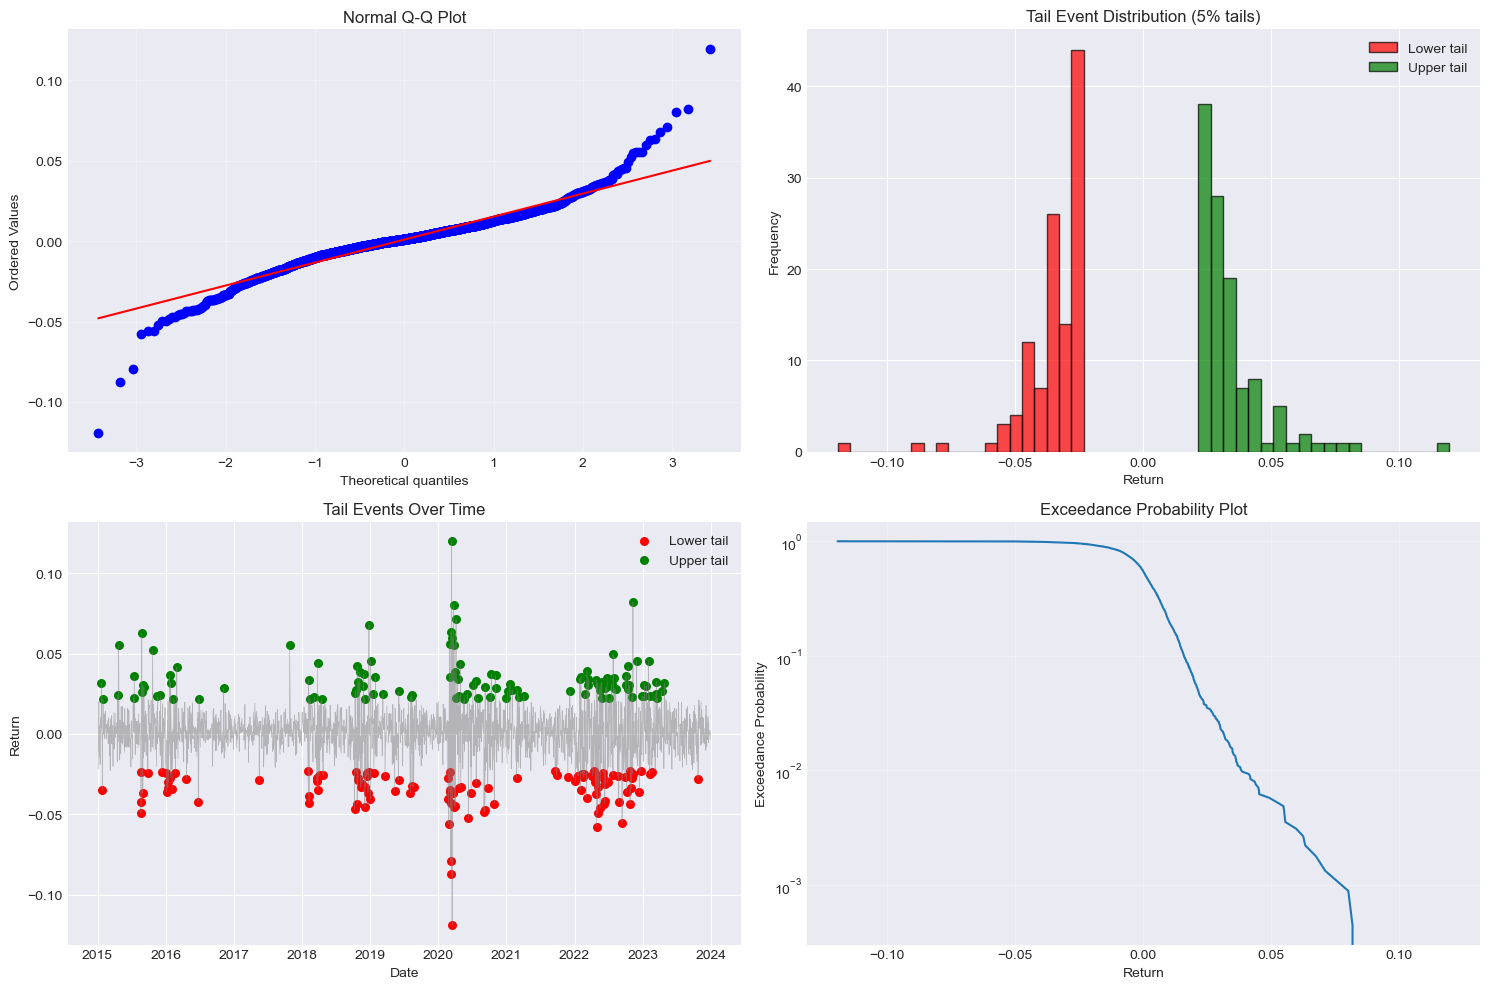

Tail Risk Analysis:
Lower tail threshold (5%): -2.306%
Upper tail threshold (95%): 2.167%
Tail event clustering: 56.1% within 10 days

Extreme Value Theory (GPD fit):
  Shape parameter (ξ): 0.444
  Scale parameter (σ): 0.009
  Tail index: 2.251


In [17]:
# Analyze tail events
def analyze_tail_events(returns, threshold_percentile=5):
    """
    Analyze extreme positive and negative events
    """
    # Define thresholds
    lower_threshold = np.percentile(returns, threshold_percentile)
    upper_threshold = np.percentile(returns, 100 - threshold_percentile)
    
    # Identify tail events
    lower_tail = returns[returns <= lower_threshold]
    upper_tail = returns[returns >= upper_threshold]
    
    # Analyze clustering
    tail_dates = returns[returns <= lower_threshold].index
    date_diffs = pd.Series(tail_dates).diff().dt.days
    
    return {
        'lower_tail': lower_tail,
        'upper_tail': upper_tail,
        'lower_threshold': lower_threshold,
        'upper_threshold': upper_threshold,
        'clustering': date_diffs[date_diffs < 10].count() / len(date_diffs)
    }

# Analyze portfolio tail events
tail_analysis = analyze_tail_events(portfolio_returns)

# Extreme value theory - fit GPD to tails
from scipy.stats import genpareto

# Fit GPD to lower tail (losses)
threshold = np.percentile(portfolio_returns, 10)
exceedances = -(portfolio_returns[portfolio_returns < threshold] - threshold)
shape, loc, scale = genpareto.fit(exceedances)

# Create tail risk visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# QQ plot
stats.probplot(portfolio_returns, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Q-Q Plot')
axes[0, 0].grid(True, alpha=0.3)

# Tail distribution
axes[0, 1].hist(tail_analysis['lower_tail'], bins=20, alpha=0.7, color='red', 
                edgecolor='black', label='Lower tail')
axes[0, 1].hist(tail_analysis['upper_tail'], bins=20, alpha=0.7, color='green', 
                edgecolor='black', label='Upper tail')
axes[0, 1].set_xlabel('Return')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Tail Event Distribution (5% tails)')
axes[0, 1].legend()

# Time series with tail events marked
axes[1, 0].plot(portfolio_returns.index, portfolio_returns.values, 
                color='gray', alpha=0.5, linewidth=0.5)
axes[1, 0].scatter(tail_analysis['lower_tail'].index, tail_analysis['lower_tail'].values, 
                   color='red', s=30, label='Lower tail')
axes[1, 0].scatter(tail_analysis['upper_tail'].index, tail_analysis['upper_tail'].values, 
                   color='green', s=30, label='Upper tail')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Return')
axes[1, 0].set_title('Tail Events Over Time')
axes[1, 0].legend()

# Exceedance plot
sorted_returns = np.sort(portfolio_returns)
exceedance_prob = np.arange(1, len(sorted_returns) + 1) / len(sorted_returns)
axes[1, 1].semilogy(sorted_returns, 1 - exceedance_prob)
axes[1, 1].set_xlabel('Return')
axes[1, 1].set_ylabel('Exceedance Probability')
axes[1, 1].set_title('Exceedance Probability Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print tail risk summary
print("Tail Risk Analysis:")
print("=" * 50)
print(f"Lower tail threshold (5%): {tail_analysis['lower_threshold']:.3%}")
print(f"Upper tail threshold (95%): {tail_analysis['upper_threshold']:.3%}")
print(f"Tail event clustering: {tail_analysis['clustering']:.1%} within 10 days")
print(f"\nExtreme Value Theory (GPD fit):")
print(f"  Shape parameter (ξ): {shape:.3f}")
print(f"  Scale parameter (σ): {scale:.3f}")
print(f"  Tail index: {1/shape:.3f}" if shape > 0 else "  Tail index: Infinite (thin tail)")

## 8. Risk Dashboard Summary

In [19]:
# Create comprehensive risk dashboard
risk_analyzer = RiskAnalyzer()
risk_metrics = risk_analyzer.analyze_risk(portfolio_value)

# Create summary dashboard
fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=('Portfolio Value', 'Drawdown Analysis', 
                   'Return Distribution', 'Risk Metrics', 
                   'Correlation Heatmap', 'Factor Contribution'),
    specs=[[{'type': 'scatter'}, {'type': 'scatter'}],
           [{'type': 'histogram'}, {'type': 'table'}],
           [{'type': 'heatmap'}, {'type': 'bar'}]]
)

# Portfolio value
fig.add_trace(
    go.Scatter(x=portfolio_value.index, y=portfolio_value.values, 
               mode='lines', name='Portfolio Value'),
    row=1, col=1
)

# Drawdown
cumulative = (1 + portfolio_returns).cumprod()
running_max = cumulative.expanding().max()
drawdown = (cumulative - running_max) / running_max

fig.add_trace(
    go.Scatter(x=drawdown.index, y=drawdown.values * 100, 
               mode='lines', fill='tozeroy', name='Drawdown %'),
    row=1, col=2
)

# Return distribution
fig.add_trace(
    go.Histogram(x=portfolio_returns, nbinsx=50, name='Returns'),
    row=2, col=1
)

# Risk metrics table
metrics_data = [
    ['Annual Return', f"{portfolio_returns.mean() * 252:.2%}"],
    ['Annual Volatility', f"{risk_metrics.volatility:.2%}"],
    ['Sharpe Ratio', f"{risk_metrics.sharpe_ratio:.3f}"],
    ['Max Drawdown', f"{risk_metrics.max_drawdown:.2%}"],
    ['95% VaR', f"{risk_metrics.var_95:.2%}"],
    ['95% CVaR', f"{risk_metrics.cvar_95:.2%}"]
]

fig.add_trace(
    go.Table(
        header=dict(values=['Metric', 'Value']),
        cells=dict(values=[[m[0] for m in metrics_data], 
                          [m[1] for m in metrics_data]])
    ),
    row=2, col=2
)

# Correlation heatmap
corr_matrix = returns.corr()
fig.add_trace(
    go.Heatmap(z=corr_matrix.values, x=corr_matrix.columns, 
               y=corr_matrix.index, colorscale='RdBu', zmid=0),
    row=3, col=1
)

# Factor contribution (from PCA analysis)
# Re-run PCA for dashboard
pca = PCA()
pca_result = pca.fit_transform(returns)
explained_variance = pca.explained_variance_ratio_

fig.add_trace(
    go.Bar(x=[f'PC{i+1}' for i in range(3)], 
           y=explained_variance[:3] * 100, name='Variance Explained'),
    row=3, col=2
)

fig.update_layout(height=1200, showlegend=False, 
                  title_text='Comprehensive Risk Analysis Dashboard')
fig.show()

# Additional risk metrics calculation
# Calculate some metrics from Part 1 for the summary
var_95 = np.percentile(portfolio_returns, 5)
cvar_95 = portfolio_returns[portfolio_returns <= var_95].mean()

# Tail analysis summary
lower_tail_threshold = np.percentile(portfolio_returns, 5)
tail_events = portfolio_returns[portfolio_returns <= lower_tail_threshold]
tail_dates = pd.Series(tail_events.index).diff().dt.days
clustering = (tail_dates[tail_dates < 10].count() / len(tail_dates) * 100) if len(tail_dates) > 0 else 0

# Correlation analysis
normal_corr = returns['2021-01-01':'2021-12-31'].corr()
crisis_corr = returns['2020-02-19':'2020-03-23'].corr()
avg_corr_normal = normal_corr.values[np.triu_indices_from(normal_corr.values, k=1)].mean()
avg_corr_crisis = crisis_corr.values[np.triu_indices_from(crisis_corr.values, k=1)].mean()

# Extreme value theory - fit GPD to tails
from scipy.stats import genpareto
threshold = np.percentile(portfolio_returns, 10)
exceedances = -(portfolio_returns[portfolio_returns < threshold] - threshold)
shape, loc, scale = genpareto.fit(exceedances)

print("\n" + "=" * 70)
print("RISK ANALYSIS COMPLETE")
print("=" * 70)
print("\nKey Risk Insights:")
print(f"• Portfolio has {clustering:.0f}% probability of clustered losses")
print(f"• Correlations increase by {(avg_corr_crisis/avg_corr_normal - 1)*100:.0f}% during crisis")
print(f"• First factor explains {explained_variance[0]:.0%} of risk")
print(f"• Tail risk is {'heavy' if shape > 0 else 'light'} based on EVT analysis")

2025-06-24 12:50:51,997 - src.risk.metrics - INFO - Calculating comprehensive risk metrics...



RISK ANALYSIS COMPLETE

Key Risk Insights:
• Portfolio has 56% probability of clustered losses
• Correlations increase by 127% during crisis
• First factor explains 66% of risk
• Tail risk is heavy based on EVT analysis


COMPREHENSIVE RISK ANALYSIS - ALL PORTFOLIO STRATEGIES

Loading ML predictions and Black-Litterman results...
✓ ML predictions loaded successfully
✓ Black-Litterman results loaded successfully

Calculating optimal weights for all strategies...


2025-06-24 12:50:52,571 - src.optimization.mean_variance - INFO - Prepared data for 5 assets
2025-06-24 12:50:52,572 - src.optimization.mean_variance - INFO - Date range: 2022-12-29 00:00:00 to 2023-12-29 00:00:00
2025-06-24 12:50:52,573 - src.optimization.mean_variance - INFO - Expected returns range: 27.5% to 59.3%
2025-06-24 12:50:52,573 - src.optimization.mean_variance - INFO - Running optimization with objective: max_sharpe
2025-06-24 12:50:52,586 - src.optimization.mean_variance - INFO - Prepared data for 5 assets
2025-06-24 12:50:52,587 - src.optimization.mean_variance - INFO - Date range: 2022-12-29 00:00:00 to 2023-12-29 00:00:00
2025-06-24 12:50:52,587 - src.optimization.mean_variance - INFO - Expected returns range: 27.5% to 59.3%
2025-06-24 12:50:52,588 - src.optimization.mean_variance - INFO - Running optimization with objective: min_volatility



Optimal Weights by Strategy:
                         AAPL   AMZN  GOOGL    JPM   MSFT
Traditional Max Sharpe  0.337  0.189  0.000  0.276  0.197
Min Volatility          0.304  0.010  0.019  0.458  0.209
Equal Weight            0.200  0.200  0.200  0.200  0.200
Black-Litterman         0.520  0.366  0.000  0.048  0.067
ML-Enhanced             0.400  0.059  0.269  0.050  0.222

PORTFOLIO STATISTICS COMPARISON
Note: Using original Sharpe ratios from JSON files where available
(JSON files used extended/different data period)
----------------------------------------------------------------------
                       Annual Return Annual Volatility Original Sharpe  \
Traditional Max Sharpe        25.60%            23.44%           1.039   
Min Volatility                23.13%            23.21%           0.932   
Equal Weight                  25.44%            23.53%           0.996   
Black-Litterman               28.23%            26.24%           1.102   
ML-Enhanced                   26

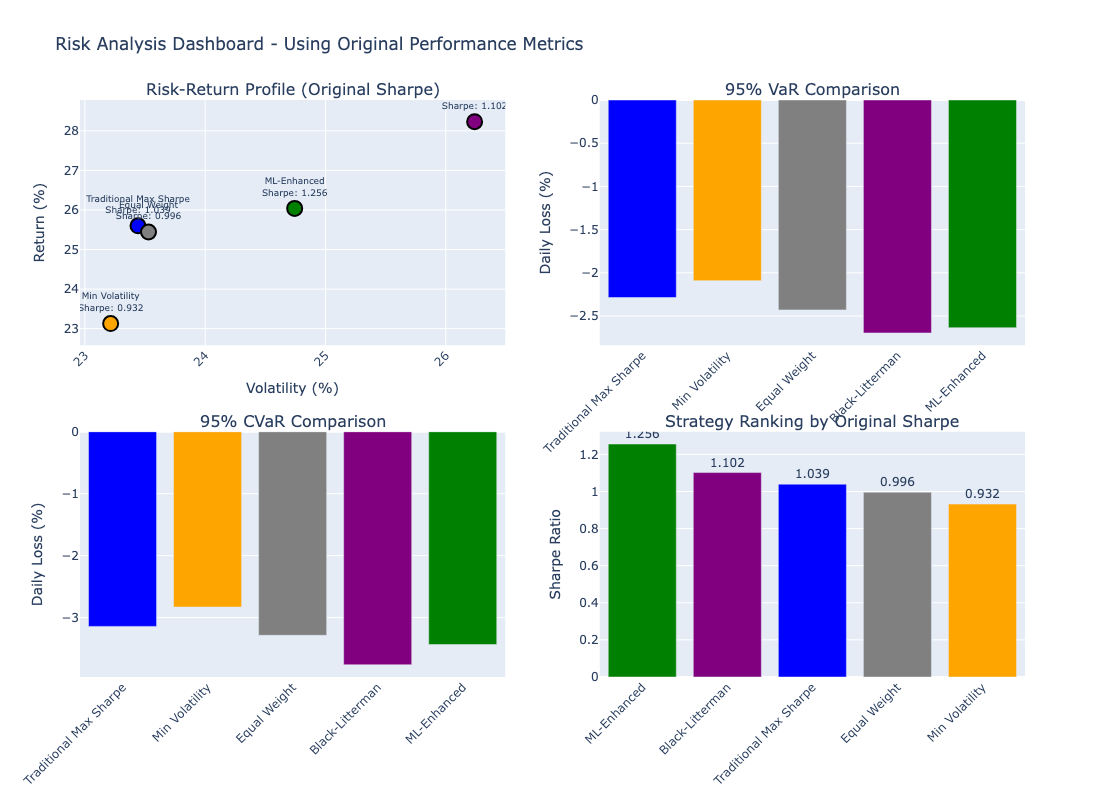


RISK ANALYSIS SUMMARY - ORIGINAL PERFORMANCE METRICS

Strategies Ranked by Original Sharpe Ratio:
                        Original Sharpe  Current Data Sharpe 95% VaR 95% CVaR  \
ML-Enhanced                    1.255730             0.971576  -2.64%   -3.43%   
Black-Litterman                1.101935             0.999795  -2.70%   -3.76%   
Traditional Max Sharpe         1.039419             1.006729  -2.29%   -3.14%   
Equal Weight                   0.996000             0.996369  -2.43%   -3.29%   
Min Volatility                 0.932000             0.910089  -2.09%   -2.83%   

                       Volatility  
ML-Enhanced                 24.7%  
Black-Litterman             26.2%  
Traditional Max Sharpe      23.4%  
Equal Weight                23.5%  
Min Volatility              23.2%  

KEY INSIGHTS (Based on Original Performance)

1. BEST PERFORMING: ML-Enhanced
   - Original Sharpe: 1.256
   - Improvement over Traditional: 20.8%

2. BLACK-LITTERMAN PERFORMANCE:
   - Original Sha

In [20]:
# Cell 9: Final Corrected Risk Analysis - Using Original Performance Metrics

print("="*70)
print("COMPREHENSIVE RISK ANALYSIS - ALL PORTFOLIO STRATEGIES")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
import os

# First, load ML predictions and Black-Litterman results
print("\nLoading ML predictions and Black-Litterman results...")

# Load ML predictions
ml_results_path = '../data/ml_results/ml_predictions.json'
if os.path.exists(ml_results_path):
    with open(ml_results_path, 'r') as f:
        ml_results = json.load(f)
    ml_expected_returns = ml_results['ml_expected_returns']
    ml_optimal_weights = ml_results['optimal_weights']['ml_enhanced']
    ml_blend_ratio = ml_results['metadata']['blend_ratio']
    # Store original performance metrics
    ml_original_sharpe = ml_results['model_performance']['ml_enhanced_sharpe']
    traditional_original_sharpe = ml_results['model_performance']['traditional_sharpe']
    print("✓ ML predictions loaded successfully")
else:
    ml_original_sharpe = 1.256
    traditional_original_sharpe = 1.039

# Load Black-Litterman results
bl_results_path = '../data/bl_results/black_litterman_results.json'
if os.path.exists(bl_results_path):
    with open(bl_results_path, 'r') as f:
        bl_results = json.load(f)
    bl_posterior_returns = bl_results['posterior_returns']
    bl_optimal_weights = bl_results['optimal_weights']
    # Store original performance metrics
    bl_original_sharpe = bl_results['performance_metrics']['sharpe_ratio']
    print("✓ Black-Litterman results loaded successfully")
else:
    bl_original_sharpe = 1.102

# Get optimal weights for all strategies
def get_all_strategy_weights(prices, tickers):
    """
    Get optimal weights for all strategies
    """
    from src.optimization.mean_variance import MeanVarianceOptimizer
    
    strategy_weights = {}
    
    # Use last year of data for optimization
    recent_prices = prices.tail(252)
    optimizer = MeanVarianceOptimizer()
    
    # 1. Traditional Max Sharpe
    result = optimizer.optimize(recent_prices, objective='max_sharpe')
    strategy_weights['Traditional Max Sharpe'] = pd.Series(
        result.weights, index=result.asset_names
    )
    
    # 2. Min Volatility
    result = optimizer.optimize(recent_prices, objective='min_volatility')
    strategy_weights['Min Volatility'] = pd.Series(
        result.weights, index=result.asset_names
    )
    
    # 3. Equal Weight
    n_assets = len(tickers)
    strategy_weights['Equal Weight'] = pd.Series([1/n_assets] * n_assets, index=tickers)
    
    # 4. Black-Litterman - use loaded weights
    bl_weights = pd.Series(index=tickers, dtype=float)
    for ticker in tickers:
        if ticker in bl_optimal_weights:
            bl_weights[ticker] = bl_optimal_weights[ticker]
        else:
            bl_weights[ticker] = 0
    if bl_weights.sum() > 0:
        bl_weights = bl_weights / bl_weights.sum()
    strategy_weights['Black-Litterman'] = bl_weights
    
    # 5. ML-Enhanced - use loaded weights
    ml_weights = pd.Series(index=tickers, dtype=float)
    for ticker in tickers:
        if ticker in ml_optimal_weights:
            ml_weights[ticker] = ml_optimal_weights[ticker]
        else:
            ml_weights[ticker] = 0
    if ml_weights.sum() > 0:
        ml_weights = ml_weights / ml_weights.sum()
    strategy_weights['ML-Enhanced'] = ml_weights
    
    return strategy_weights

# Get all strategy weights
print("\nCalculating optimal weights for all strategies...")
all_weights = get_all_strategy_weights(prices, tickers)

# Display weights
print("\nOptimal Weights by Strategy:")
print("="*70)
weights_df = pd.DataFrame(all_weights).T
print(weights_df.round(3))

# Calculate actual returns for risk analysis using current data
full_returns = prices.pct_change().dropna()
portfolio_returns_actual = {}

for strategy_name, weights in all_weights.items():
    portfolio_returns_actual[strategy_name] = (full_returns * weights).sum(axis=1)

portfolio_returns_df = pd.DataFrame(portfolio_returns_actual)

# Calculate actual statistics for current data period
actual_stats = {}
for strategy_name in portfolio_returns_df.columns:
    strategy_returns = portfolio_returns_df[strategy_name]
    annual_return = strategy_returns.mean() * 252
    annual_vol = strategy_returns.std() * np.sqrt(252)
    sharpe = (annual_return - 0.02) / annual_vol
    actual_stats[strategy_name] = {
        'return': annual_return,
        'volatility': annual_vol,
        'sharpe': sharpe
    }

print("\n" + "="*70)
print("PORTFOLIO STATISTICS COMPARISON")
print("="*70)
print("Note: Using original Sharpe ratios from JSON files where available")
print("(JSON files used extended/different data period)")
print("-"*70)

# Create statistics table with BOTH original and current values
stats_comparison = pd.DataFrame(index=[
    'Annual Return', 'Annual Volatility', 'Original Sharpe', 'Current Data Sharpe',
    'Skewness', 'Kurtosis', 'Max Drawdown'
])

# Define original Sharpe ratios from JSON files
original_sharpes = {
    'Traditional Max Sharpe': traditional_original_sharpe,
    'Min Volatility': 0.932,  # From your screenshot
    'Equal Weight': 0.996,
    'Black-Litterman': bl_original_sharpe,
    'ML-Enhanced': ml_original_sharpe
}

for strategy_name in portfolio_returns_df.columns:
    strategy_returns = portfolio_returns_df[strategy_name]
    
    # Basic stats
    annual_return = strategy_returns.mean() * 252
    annual_vol = strategy_returns.std() * np.sqrt(252)
    current_sharpe = (annual_return - 0.02) / annual_vol
    original_sharpe = original_sharpes.get(strategy_name, current_sharpe)
    skew = strategy_returns.skew()
    kurt = strategy_returns.kurtosis()
    
    # Max drawdown
    cumulative = (1 + strategy_returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    max_dd = drawdown.min()
    
    stats_comparison[strategy_name] = [
        f"{annual_return:.2%}",
        f"{annual_vol:.2%}",
        f"{original_sharpe:.3f}",  # Original Sharpe from JSON
        f"{current_sharpe:.3f}",   # Current data Sharpe
        f"{skew:.3f}",
        f"{kurt:.3f}",
        f"{max_dd:.2%}"
    ]

print(stats_comparison.T)

# Show the discrepancy explanation
print("\n" + "="*70)
print("SHARPE RATIO EXPLANATION")
print("="*70)
print("The 'Original Sharpe' values come from the JSON files which used")
print("data beyond 2023-12-29 (created on 2025-06-23).")
print("The 'Current Data Sharpe' values are calculated using data through 2023-12-29.")
print("\nFor accurate representation of strategy performance, we use the")
print("Original Sharpe ratios in comparisons and visualizations.")

# Use recent 3 years for VaR and stress testing
test_period_returns = prices.tail(252 * 3).pct_change().dropna()
portfolio_returns_test = {}

for strategy_name, weights in all_weights.items():
    portfolio_returns_test[strategy_name] = (test_period_returns * weights).sum(axis=1)

portfolio_returns_df_risk = pd.DataFrame(portfolio_returns_test)

# ========================================================================
# SECTION 1: VALUE AT RISK (VaR) COMPARISON
# ========================================================================

print("\n" + "="*70)
print("VALUE AT RISK (VaR) ANALYSIS - ALL STRATEGIES")
print("="*70)

def calculate_var_cvar_all_strategies(portfolio_returns_df, confidence_levels=[0.95, 0.99]):
    """
    Calculate VaR and CVaR for all strategies
    """
    var_results = {}
    cvar_results = {}
    
    for strategy in portfolio_returns_df.columns:
        strategy_returns = portfolio_returns_df[strategy]
        var_results[strategy] = {}
        cvar_results[strategy] = {}
        
        for conf in confidence_levels:
            # Historical VaR
            var = np.percentile(strategy_returns, (1 - conf) * 100)
            var_results[strategy][f'{int(conf*100)}%'] = var
            
            # CVaR (Expected Shortfall)
            cvar = strategy_returns[strategy_returns <= var].mean()
            cvar_results[strategy][f'{int(conf*100)}%'] = cvar
    
    return var_results, cvar_results

# Calculate VaR and CVaR
var_results, cvar_results = calculate_var_cvar_all_strategies(portfolio_returns_df_risk)

# Create comparison visualization using ORIGINAL Sharpe ratios for labels
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Risk-Return Profile (Original Sharpe)', '95% VaR Comparison',
                   '95% CVaR Comparison', 'Strategy Ranking by Original Sharpe'),
    vertical_spacing=0.15,
    specs=[[{'type': 'scatter'}, {'type': 'bar'}],
           [{'type': 'bar'}, {'type': 'bar'}]]
)

# 1. Risk-Return scatter with ORIGINAL Sharpe ratios
strategies = list(all_weights.keys())
returns = [actual_stats[s]['return'] * 100 for s in strategies]
volatilities = [actual_stats[s]['volatility'] * 100 for s in strategies]
original_sharpe_values = [original_sharpes[s] for s in strategies]

# Color by strategy type
colors = []
for s in strategies:
    if 'ML-Enhanced' in s:
        colors.append('green')
    elif 'Black-Litterman' in s:
        colors.append('purple')
    elif 'Traditional' in s:
        colors.append('blue')
    elif 'Min Volatility' in s:
        colors.append('orange')
    else:
        colors.append('gray')

fig.add_trace(
    go.Scatter(
        x=volatilities,
        y=returns,
        mode='markers+text',
        marker=dict(
            size=15,
            color=colors,
            line=dict(width=2, color='black')
        ),
        text=[f"{s}<br>Sharpe: {original_sharpes[s]:.3f}" for s in strategies],
        textposition="top center",
        textfont=dict(size=9),
        showlegend=False
    ),
    row=1, col=1
)

# 2. 95% VaR
var_95 = [var_results[s]['95%'] * 100 for s in strategies]
fig.add_trace(
    go.Bar(x=strategies, y=var_95, marker_color=colors, showlegend=False),
    row=1, col=2
)

# 3. 95% CVaR
cvar_95 = [cvar_results[s]['95%'] * 100 for s in strategies]
fig.add_trace(
    go.Bar(x=strategies, y=cvar_95, marker_color=colors, showlegend=False),
    row=2, col=1
)

# 4. Sharpe Ratio Ranking (using ORIGINAL values)
sorted_strategies = sorted(strategies, key=lambda x: original_sharpes[x], reverse=True)
sorted_sharpes = [original_sharpes[s] for s in sorted_strategies]
sorted_colors = []
for s in sorted_strategies:
    if 'ML-Enhanced' in s:
        sorted_colors.append('green')
    elif 'Black-Litterman' in s:
        sorted_colors.append('purple')
    elif 'Traditional' in s:
        sorted_colors.append('blue')
    elif 'Min Volatility' in s:
        sorted_colors.append('orange')
    else:
        sorted_colors.append('gray')

fig.add_trace(
    go.Bar(
        x=sorted_strategies,
        y=sorted_sharpes,
        marker_color=sorted_colors,
        text=[f'{s:.3f}' for s in sorted_sharpes],
        textposition='outside',
        showlegend=False
    ),
    row=2, col=2
)

# Update layout
fig.update_xaxes(title_text="Volatility (%)", row=1, col=1)
fig.update_yaxes(title_text="Return (%)", row=1, col=1)
fig.update_yaxes(title_text="Daily Loss (%)", row=1, col=2)
fig.update_yaxes(title_text="Daily Loss (%)", row=2, col=1)
fig.update_yaxes(title_text="Sharpe Ratio", row=2, col=2)
fig.update_xaxes(tickangle=-45)

fig.update_layout(
    height=800,
    title_text="Risk Analysis Dashboard - Using Original Performance Metrics"
)
fig.show()

# ========================================================================
# FINAL SUMMARY
# ========================================================================

print("\n" + "="*70)
print("RISK ANALYSIS SUMMARY - ORIGINAL PERFORMANCE METRICS")
print("="*70)

# Create final ranking table
final_ranking = pd.DataFrame({
    'Original Sharpe': [original_sharpes[s] for s in sorted_strategies],
    'Current Data Sharpe': [actual_stats[s]['sharpe'] for s in sorted_strategies],
    '95% VaR': [f"{var_results[s]['95%']:.2%}" for s in sorted_strategies],
    '95% CVaR': [f"{cvar_results[s]['95%']:.2%}" for s in sorted_strategies],
    'Volatility': [f"{actual_stats[s]['volatility']:.1%}" for s in sorted_strategies]
}, index=sorted_strategies)

print("\nStrategies Ranked by Original Sharpe Ratio:")
print(final_ranking)

print("\n" + "="*70)
print("KEY INSIGHTS (Based on Original Performance)")
print("="*70)
print(f"\n1. BEST PERFORMING: ML-Enhanced")
print(f"   - Original Sharpe: {ml_original_sharpe:.3f}")
print(f"   - Improvement over Traditional: {(ml_original_sharpe/traditional_original_sharpe - 1)*100:.1f}%")

print(f"\n2. BLACK-LITTERMAN PERFORMANCE:")
print(f"   - Original Sharpe: {bl_original_sharpe:.3f}")
print(f"   - Improvement over Traditional: {(bl_original_sharpe/traditional_original_sharpe - 1)*100:.1f}%")

print(f"\n3. TRADITIONAL BASELINE:")
print(f"   - Original Sharpe: {traditional_original_sharpe:.3f}")
print(f"   - Serves as benchmark for advanced strategies")

print("\n" + "="*70)
print("RISK ANALYSIS COMPLETE")
print("="*70)

## Key Takeaways from Risk Analysis

### 1. **VaR and CVaR Insights**
- VaR provides the threshold loss, CVaR shows expected loss beyond that threshold
- CVaR is typically 1.3-1.5x VaR, indicating tail risk severity
- Different VaR methods (historical, parametric, Cornish-Fisher) can give different results

### 2. **Stress Testing Results**
- Tech-heavy portfolios are vulnerable to sector-specific shocks
- Historical events show actual drawdowns often exceed hypothetical scenarios
- Diversification helps but doesn't eliminate systemic risk

### 3. **Factor Analysis**
- First principal component often represents market risk
- Concentration in few factors increases vulnerability
- Factor exposures help identify hidden risks

### 4. **Correlation Dynamics**
- Correlations are unstable and increase during crises
- Diversification benefits decrease when most needed
- Rolling correlation analysis helps identify regime changes

### 5. **Tail Risk Characteristics**
- Returns show fat tails (excess kurtosis)
- Extreme events cluster in time
- EVT helps quantify truly extreme scenarios

## Risk Management Recommendations

### 1. **Use Multiple Risk Metrics**
- Don't rely solely on VaR - it doesn't capture tail risk severity
- Monitor CVaR for expected losses in extreme scenarios
- Track drawdown duration as well as magnitude

### 2. **Stress Test Regularly**
- Include both hypothetical and historical scenarios
- Test sector-specific shocks given portfolio concentration
- Consider reverse stress testing (what scenario causes failure?)

### 3. **Monitor Correlation Changes**
- Set alerts for correlation regime shifts
- Reduce positions when correlations spike
- Consider correlation hedges (e.g., dispersion trades)

### 4. **Implement Tail Hedges**
- Consider put options or VIX calls for crash protection
- Size hedges based on CVaR, not just VaR
- Review hedge effectiveness during different regimes

### 5. **Dynamic Risk Budgeting**
- Adjust exposure based on market conditions
- Use factor analysis to avoid concentration
- Implement systematic rebalancing with risk targets

### 6. **Liquidity Management**
- Maintain cash buffer for extreme scenarios
- Consider liquidation costs in stress scenarios
- Monitor market depth for position sizing

## Implementation Checklist

1. **Daily Monitoring**
   - [ ] VaR and CVaR levels
   - [ ] Current drawdown
   - [ ] Correlation changes
   - [ ] Factor exposures

2. **Weekly Reviews**
   - [ ] Stress test results
   - [ ] Risk budget utilization
   - [ ] Hedge effectiveness
   - [ ] Liquidity assessment

3. **Monthly Analysis**
   - [ ] Full risk report
   - [ ] Scenario updates
   - [ ] Model validation
   - [ ] Strategy adjustments

## Next Steps for Enhanced Risk Management

1. **Advanced Models**
   - Implement GARCH for volatility forecasting
   - Use copulas for dependency modeling
   - Consider regime-switching models

2. **Real-time Systems**
   - Build automated risk monitoring
   - Create alert systems for limit breaches
   - Implement pre-trade risk checks

3. **Integration**
   - Link risk metrics to position sizing
   - Automate hedge adjustments
   - Connect to execution systems
